In [1]:
import os
from pathlib import Path
import sys
import numpy as np
import scvelo as scv

In [3]:
notebook_dir = os.getcwd()
notebook_dir

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github\\STVelo\\notebooks\\analysis\\nuc_cyto_vs_spl_uns'

In [4]:
Path(notebook_dir).parents[3]

WindowsPath('c:/Users/OmerCagatayTalikaci/Desktop/github')

In [5]:
os.chdir(Path(notebook_dir).parents[3])

In [6]:
stvelo_path = os.path.join(os.getcwd(),'STVelo','stvelo')

import sys  
sys.path.insert(1,stvelo_path)

from pipelines.metrics import *

# Read adatas 

In [7]:
adata_folder_path = os.path.join(os.getcwd(), 'data', 'sim2') 

In [15]:
import os
import anndata as ad


# Initialize an empty dictionary to store the AnnData objects
adata_dict = {}

# Loop through all files in the folder
for file_name in os.listdir(adata_folder_path):
    # Check if the file has .h5ad extension
    if file_name.endswith('.h5ad'):
        # Remove the file extension to use as the dictionary key
        key = os.path.splitext(file_name)[0]
        
        # Read the .h5ad file and store it in the dictionary
        adata_dict[key] = scv.read(os.path.join(adata_folder_path, file_name))

# Now, adata_dict contains the .h5ad files with keys as their filenames without extension


In [16]:
adatas = {k:v.copy() for k,v in adata_dict.items()}

In [17]:
# adata shuffled 
spliced_n_c = adatas['adata_n_c_800obs_300genes_deterministic'].layers['spliced']

for col in range(spliced_n_c.shape[1]):
    np.random.shuffle(spliced_n_c[:, col])


In [18]:
unspliced_n_c = adatas['adata_n_c_800obs_300genes_deterministic'].layers['unspliced']

for col in range(unspliced_n_c.shape[1]):
    np.random.shuffle(unspliced_n_c[:, col])

In [19]:
adata_random = adatas['adata_n_c_800obs_300genes_deterministic'].copy()

In [20]:
adata_random.layers['spliced'] = spliced_n_c
adata_random.layers['unspliced'] = unspliced_n_c
adata_random.X = spliced_n_c+unspliced_n_c

In [21]:
adata_dict['adata_n_c_800obs_300genes_deterministic'].layers['spliced']

array([[  1.85260364,   0.        , 298.16734688, ...,  25.07434586,
          0.        ,   1.1971392 ],
       [  3.60566095,   0.        ,   0.        , ...,   0.        ,
          0.        ,  16.12224565],
       [129.76177502,  20.3950838 , 190.88302245, ...,   0.        ,
          0.        ,   0.        ],
       ...,
       [113.28264322,   0.        ,   4.96896648, ...,   4.09480481,
         13.87819377,   2.1817908 ],
       [113.8010774 ,   0.        ,  57.67910763, ...,   1.78947846,
         40.28809389,  16.76033087],
       [ 16.79435799,  19.86372143,   0.        , ...,   0.        ,
         11.6872018 ,   0.        ]])

In [22]:
adata_dict['random'] = adata_random

# n_obs = 800

In [23]:
adata_800 = {'adata_n_c_800obs_300genes_deterministic': adata_dict['adata_n_c_800obs_300genes_deterministic'].copy(),
             'adata_s_u_800obs_300genes_deterministic': adata_dict['adata_s_u_800obs_300genes_deterministic'].copy()}

In [24]:
adata_n_c_800obs = adata_dict['adata_n_c_800obs_300genes_deterministic'].copy()
adata_s_u_800obs = adata_dict['adata_s_u_800obs_300genes_deterministic'].copy()

In [25]:
import matplotlib.pyplot as plt 

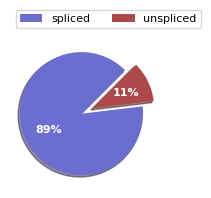

In [26]:
scv.pl.proportions(adata_800['adata_s_u_800obs_300genes_deterministic'])

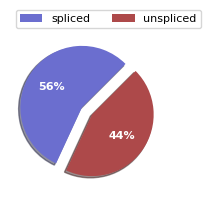

In [27]:
scv.pl.proportions(adata_800['adata_n_c_800obs_300genes_deterministic'])

# Metrics 

# Confidence 

- Confidence metric measures the mean velocity consistency by calculating the pearson correlation between a cell and its neighbours. Let $v(x_j)$ be the velocity of cell $x_j$. Confidence $c_j$ is given by;

$$c_j = \frac{1}{k} \sum_{x \in \mathit{N_k(x_j)} } corr(v(x_j),v(x))$$

where $\mathit{N_k(x_j)}$ is the k-neighbours of $x_j$ in KNN graph.


sc.pp.neighbors(adata) > scv.tl.velocity() > scv.tl.velocity_graph() to compute cosine corr. > scv.tl.velocity_confidence()

In [12]:
for d in adata_800.keys():
    print(d)
    adata_800[d]=compute_confidence(adata_800[d])

adata_n_c_800obs_300genes_deterministic
computing velocity graph (using 2/24 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:00:11) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
adata_s_u_800obs_300genes_deterministic
computing velocity graph (using 2/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)


<Axes: xlabel='Velocity confidence', ylabel='velo_type'>

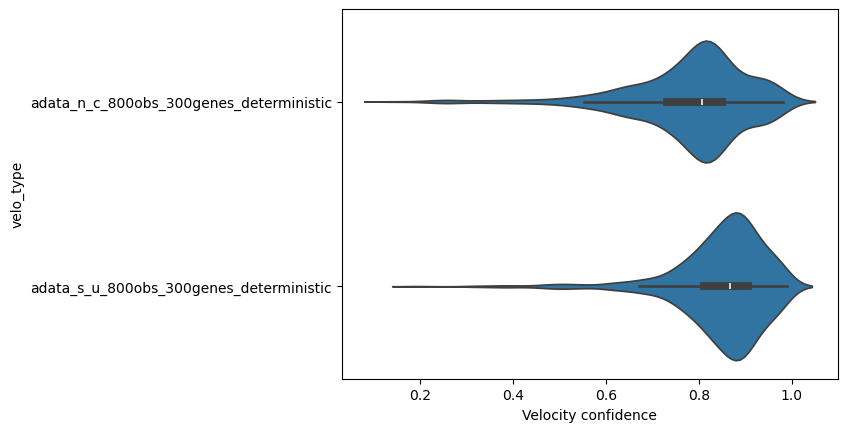

In [13]:
# confidence
import seaborn as sns
confidences=get_confidences(adata_800)
sns.violinplot(data=confidences,x='Velocity confidence',y='velo_type')

- velocities looks consistent for the neighbours in KNN for both of the model. Nuc - cyto model has better mean.

- similar performances between models was expected as the total sum is same. For further investigation we can check if there is a difference in leidens groups.  

- noise for these datas are bigger thatn the 01_analysis and it look like noise effects n_c model more for the local consistancy.

- more counts make the model more robost implies noise effects nuclein cyto more. 



In [14]:
import matplotlib.pyplot as plt

In [20]:
leiden_clusters = adata_800['adata_n_c_800obs_300genes_deterministic'].obs['leiden']

In [21]:
leiden_clusters = pd.concat([leiden_clusters,leiden_clusters])

In [22]:
leiden_clusters.reset_index(inplace=True, drop=True)

In [23]:
confidences.reset_index(inplace=True, drop=True)

In [24]:
confidences['leiden'] =leiden_clusters

<Axes: xlabel='cell_id', ylabel='Velocity confidence'>

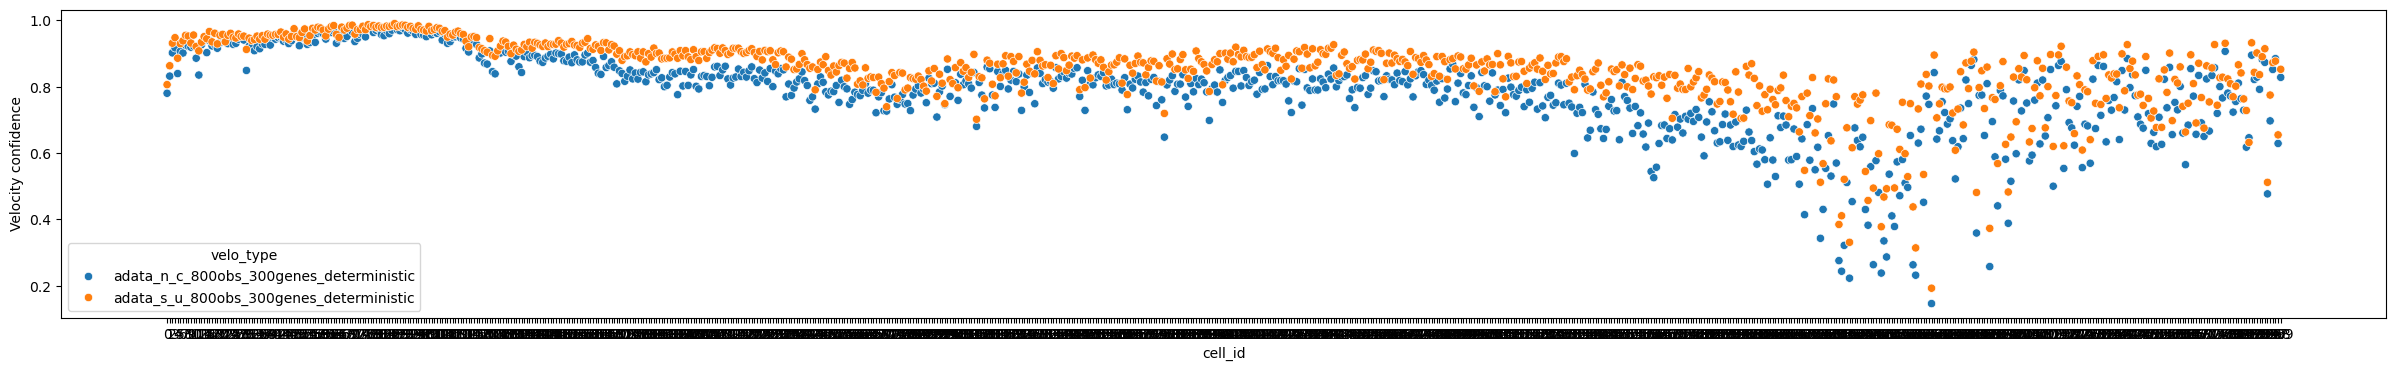

In [25]:
plt.figure(figsize=(30,4))
sns.scatterplot(data=confidences,x='cell_id',y= 'Velocity confidence', hue='velo_type')

<Axes: xlabel='cell_id', ylabel='Velocity confidence'>

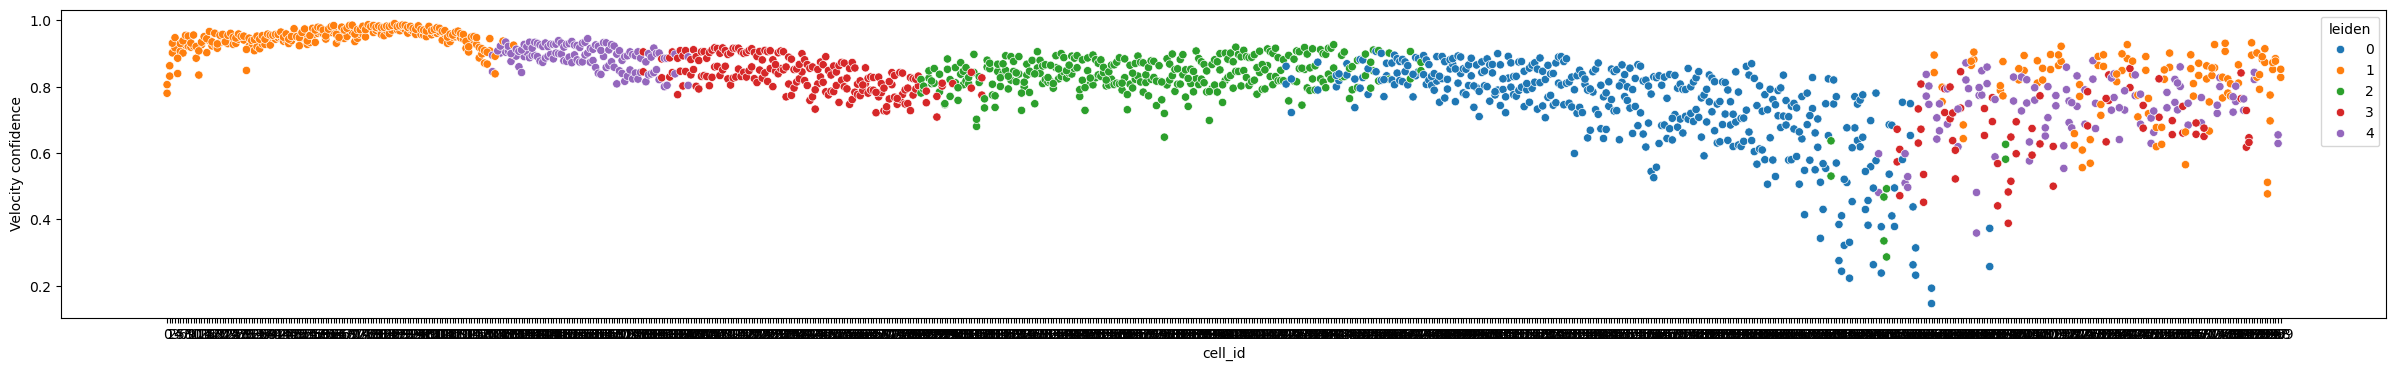

In [26]:
plt.figure(figsize=(30,4))
sns.scatterplot(data=confidences,x='cell_id',y= 'Velocity confidence', hue='leiden')

In [27]:
confidences.groupby(['velo_type','leiden'])['Velocity confidence'].mean()

velo_type                                leiden
adata_n_c_800obs_300genes_deterministic  0         0.680813
                                         1         0.890113
                                         2         0.799332
                                         3         0.760218
                                         4         0.789002
adata_s_u_800obs_300genes_deterministic  0         0.788621
                                         1         0.916921
                                         2         0.856813
                                         3         0.828320
                                         4         0.846804
Name: Velocity confidence, dtype: float64

- it can be seen from the graphs above that the overall performance velocity consistency is looks same for most of the groups.
- for l-4 and l-5 velocity consistency is better for the spl - uns approach, wheras for l-0 nuc-cyt model gives better scores. Reason?
    - assumption 1. : differences in counts might effect the overal perf of specfic groups. velocity genes can be checked.
    - deterministic model assumes beta = 1. as total spliced counts > cyto counts, for groups which have cells near steady state, difference in the counts make dynamics more clear or vouge. Velocity lenghts might be checked. 

## Velocity length for different leiden clusters  

In [28]:
adata_800['adata_n_c_800obs_300genes_deterministic'].obs.groupby('leiden')['velocity_length'].mean()

leiden
0    237.740829
1    453.092987
2    353.275055
3    316.103516
4    351.011292
Name: velocity_length, dtype: float32

In [29]:
adata_800['adata_s_u_800obs_300genes_deterministic'].obs.groupby('leiden')['velocity_length'].mean()

leiden
0     68.244095
1    148.154984
2    115.598907
3     97.264740
4    106.864616
Name: velocity_length, dtype: float32

- velocity lengths are much bigger in nuc cyt model. However this shouldn't directly influence pearson correlation since the difference in vectors normalized by their norms.  

In [30]:
spl = adata_800['adata_s_u_800obs_300genes_deterministic'].layers['spliced'] 
uns = adata_800['adata_s_u_800obs_300genes_deterministic'].layers['unspliced']
nuc = adata_800['adata_n_c_800obs_300genes_deterministic'].layers['spliced']
cyt = adata_800['adata_n_c_800obs_300genes_deterministic'].layers['unspliced']

In [31]:
np.sum(uns,axis=0)/np.sum(spl,axis=0)

array([0.03751267, 0.3147836 , 0.09217325, 0.36479607, 0.21275814,
       0.05710134, 0.13492449, 0.09073588, 0.24500992, 0.11960735,
       0.4360777 , 0.14947087, 0.10950414, 0.05805673, 0.26849627,
       0.4102439 , 0.17342332, 0.13129651, 0.03659479, 0.04474214,
       0.06723806, 0.08368189, 0.04262014, 0.09228581, 0.07464543,
       0.08708943, 0.11781449, 0.11844282, 0.1232484 , 0.12465324,
       0.26394946, 0.10908892, 0.38973562, 0.1514656 , 0.22225024,
       0.03145789, 0.17542128, 0.06530971, 0.13326331, 0.21191733,
       0.18709793, 0.24241219, 0.09214334, 0.31344821, 0.2375496 ,
       0.08543988, 0.13357798, 0.1638031 , 0.16015349, 0.07374467,
       0.07385165, 0.14852444, 0.36098977, 0.15033468, 0.11345368,
       0.10039902, 0.1308765 , 0.06489639, 0.30862237, 0.25359468,
       0.17692029, 0.09483177, 0.25738718, 0.45607488, 0.09745869,
       0.10126201, 0.0796768 , 0.24001366, 0.16580233, 0.09508586,
       0.08077606, 0.02987915, 0.06576895, 0.1905083 , 0.03101

In [32]:
adata_800['adata_s_u_800obs_300genes_deterministic'].var.velocity_gamma

0      0.037515
1      0.310046
2      0.089633
3      0.371787
4      0.206863
         ...   
295    0.310316
296    0.419122
297    0.078657
298    0.115094
299    0.122477
Name: velocity_gamma, Length: 300, dtype: float32

For deterministic model $\beta = 1 $. velocity gamma is given by $\frac{n}{s}$ for cells which is the value for having the steady state, and velocity $\frac{ds}{dt} = u - \gamma s$ 

# Velocity Correlation by gene

Checks if the velocities calculated for the same gene in different modalities are consistent. 

In [28]:
velocity_correlation_by_gene=velocity_corr_against_reference(adata_800,reference='adata_s_u_800obs_300genes_deterministic', mode= 'by_gene')

Text(0, 0.5, 'Modality')

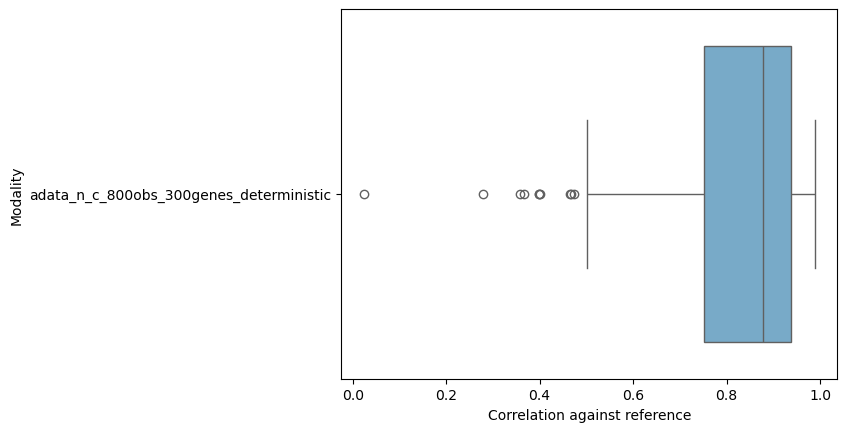

In [29]:
# velocity corr against a reference 
# import matplotlib.pyplot as plt
# sns.clustermap(velocity_correlation_by_gene.fillna(0),figsize=(7,4),cmap='Blues')
# sns.scatterplot(velocity_correlation_by_gene[:1].T)
# plt.figure(figsize=(5,5))
sns.boxplot(data=velocity_correlation_by_gene[:1].stack().reset_index(),y='level_0',x=0,palette='Blues')
plt.xlabel('Correlation against reference')
plt.ylabel('Modality')


- It looks like the model capture more or less the same dynamics for the genes in two modalities. Investigate lover correlations:

In [30]:
velo_genes_s_u = adata_800['adata_s_u_800obs_300genes_deterministic'].var['velocity_genes']
velo_genes_n_c = adata_800['adata_n_c_800obs_300genes_deterministic'].var['velocity_genes']

In [31]:
print(velo_genes_n_c.value_counts(),velo_genes_s_u.value_counts())

velocity_genes
True     255
False     45
Name: count, dtype: int64 velocity_genes
True     248
False     52
Name: count, dtype: int64


In [32]:
a = pd.DataFrame(velocity_correlation_by_gene.T)
a['velo_gene_s_u'] = velo_genes_s_u
a['velo_genes_u_n'] = velo_genes_n_c

In [33]:
a.iloc[0:,:4].sort_values('adata_n_c_800obs_300genes_deterministic').head(-5)


,adata_n_c_800obs_300genes_deterministic,adata_s_u_800obs_300genes_deterministic,velo_gene_s_u,velo_genes_u_n
147,0.024071,1.0,True,True
264,0.277725,1.0,True,True
19,0.358644,1.0,True,True
42,0.366099,1.0,True,True
179,0.397652,1.0,True,True
...,...,...,...,...
207,0.979430,1.0,True,True
183,0.981119,1.0,True,True
81,0.982333,1.0,True,True
2,0.982675,1.0,True,True


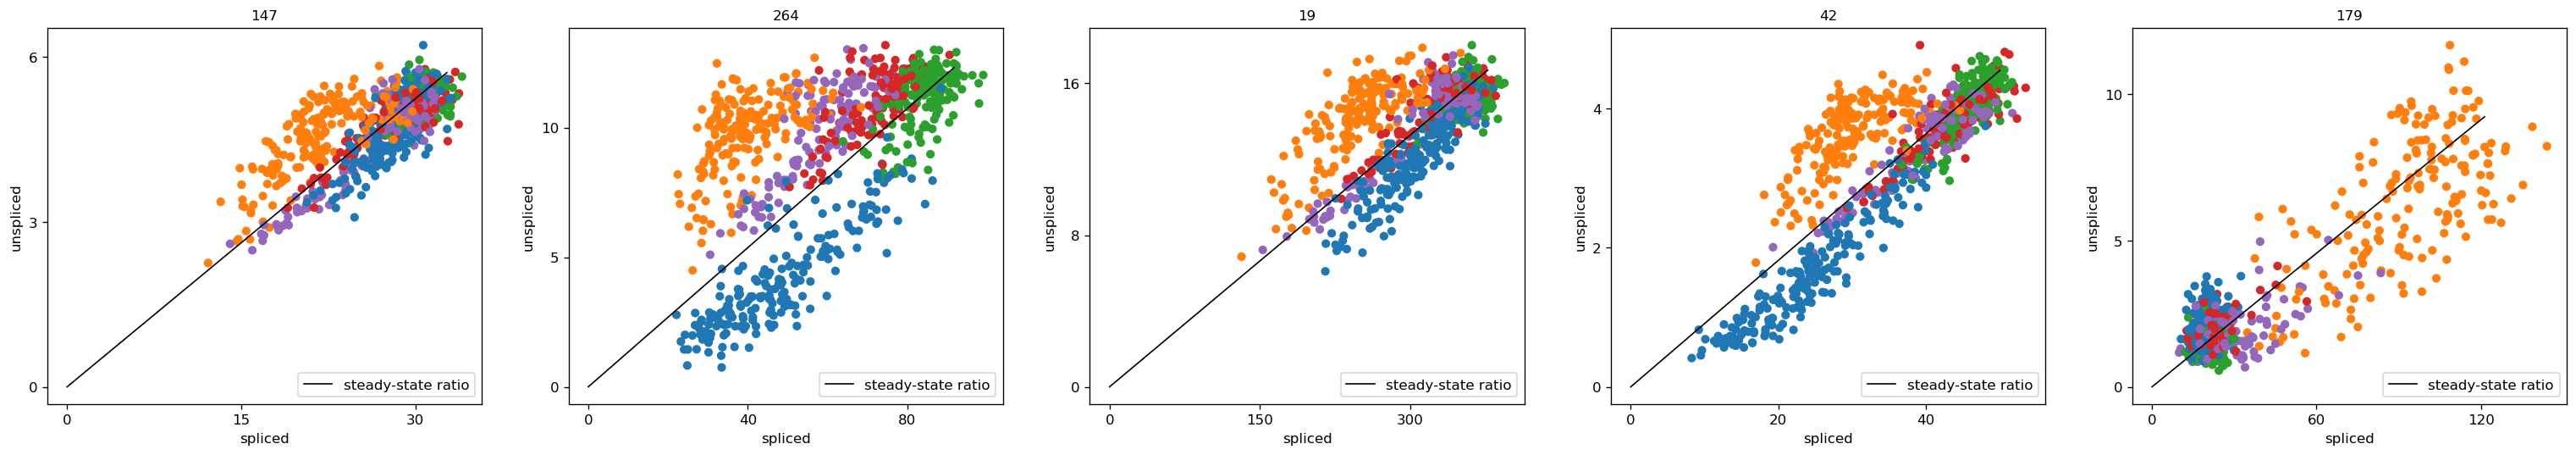

In [44]:
scv.pl.scatter(adata_s_u_800obs,color="leiden", basis=['147','264','19','42','179'], ncols=5, frameon=True,dpi=120)

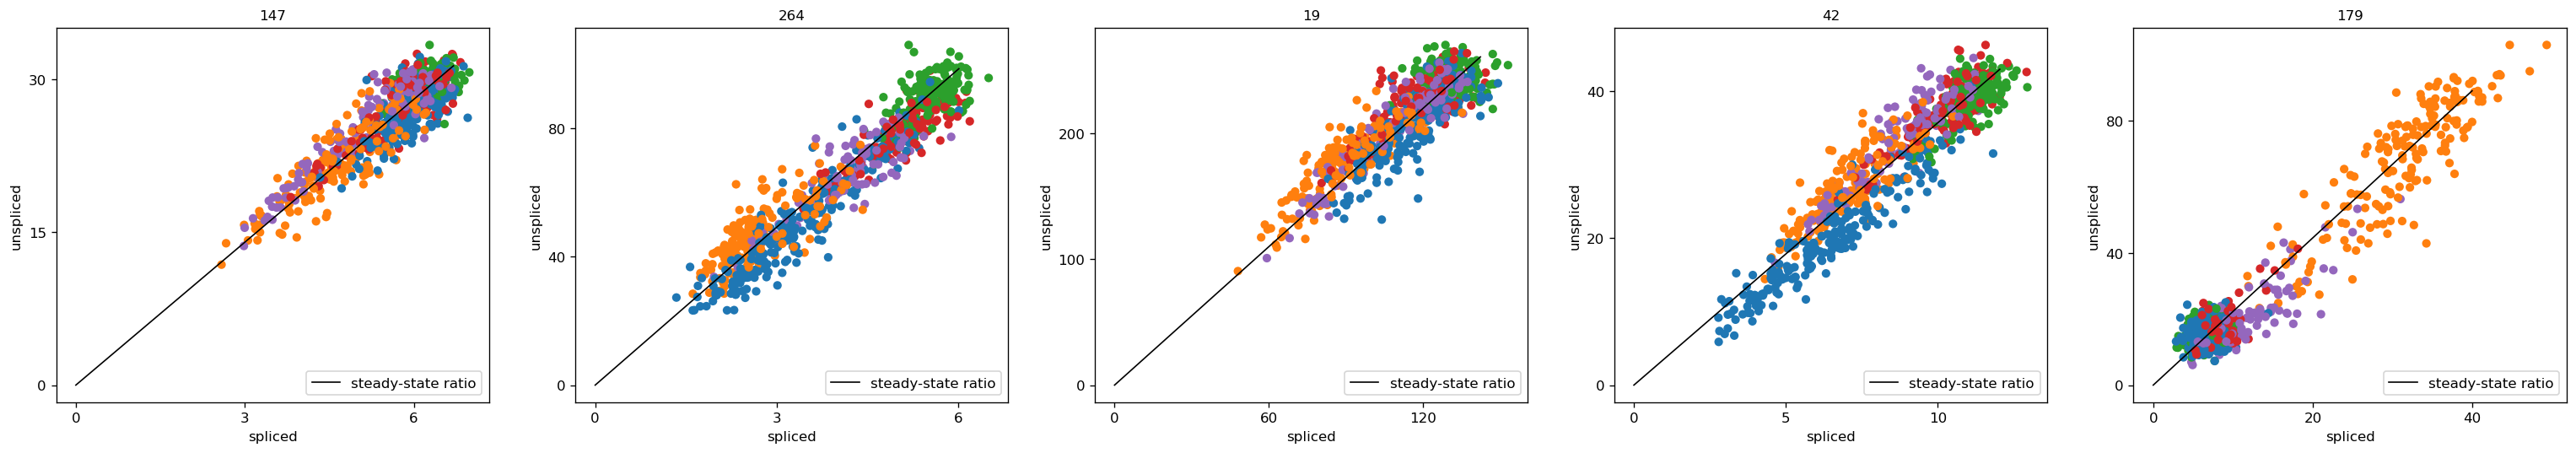

In [45]:
scv.pl.scatter(adata_n_c_800obs,color="leiden", basis=['147','264','19','42','179'], ncols=5, frameon=True,dpi=120)

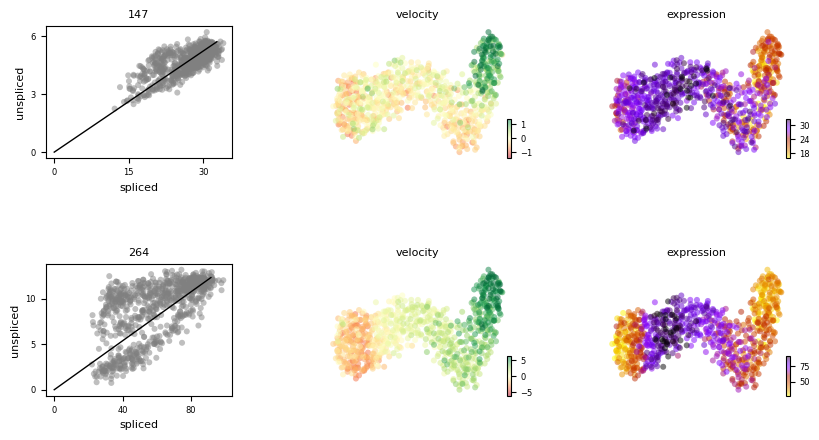

In [151]:
scv.pl.velocity(adata_s_u_800obs, ['147','264'])

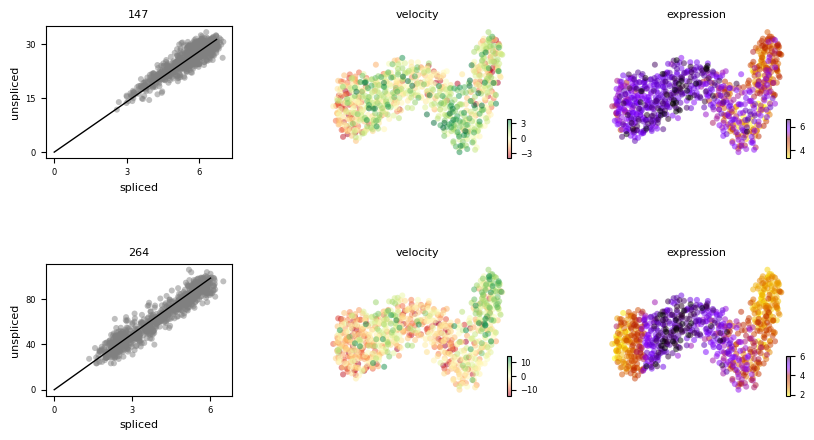

In [150]:
scv.pl.velocity(adata_n_c_800obs, ['147','264'])


In [74]:
adata_s_u_800obs.var.iloc[264,]

true_t_                11.044318
true_alpha             46.350653
true_beta               3.933081
true_nu                 0.561133
true_gamma              7.689878
true_scaling                 1.0
n_cells                      772
velocity_gamma          0.134229
velocity_qreg_ratio     0.134229
velocity_r2             0.238813
velocity_genes              True
Name: 264, dtype: object

In [73]:
adata_n_c_800obs.var.iloc[264,]

true_t_                11.044318
true_alpha             46.350653
true_beta               3.933081
true_nu                 0.561133
true_gamma              7.689878
true_scaling                 1.0
n_cells                      772
velocity_gamma         16.396784
velocity_qreg_ratio    16.396784
velocity_r2             0.890753
velocity_genes              True
Name: 264, dtype: object

In [72]:
(np.sum(adata_n_c_800obs.layers['unspliced'], axis=0) / np.sum(adata_n_c_800obs.layers['spliced'], axis=0))[264]

15.887669227475437

In [71]:
(np.sum(adata_s_u_800obs.layers['unspliced'], axis=0) / np.sum(adata_s_u_800obs.layers['spliced'], axis=0))[264]

0.14437986759071694

In [87]:
print (np.sum(adata_n_c_800obs.layers['velocity'],axis=0)[264], np.sum(adata_s_u_800obs.layers['velocity'],axis=0)[264]) 

-1655.3683 721.7445


In [89]:
(np.sum(adata_n_c_800obs.to_df('unspliced'),axis=0)/np.sum(adata_n_c_800obs.to_df('spliced'),axis=0)).sort_values()

199     0.137001
239     0.179842
71      0.185628
228     0.187486
140     0.193348
         ...    
246     7.425648
291     8.243524
259     8.331081
58     13.270934
264    15.887669
Length: 300, dtype: float64

In [77]:
# shuffle the gene counts for s and u, create new expression metrics to put in X.   
adata_n_c_800obs.layers['spliced'].shape

(800, 300)

# Velocity correlation by cell 

In [90]:
velocity_correlation_by_cell=velocity_corr_against_reference(adata_800,reference='adata_s_u_800obs_300genes_deterministic', mode= 'by_cell')

Text(0.5, 0, 'Correlation against reference')

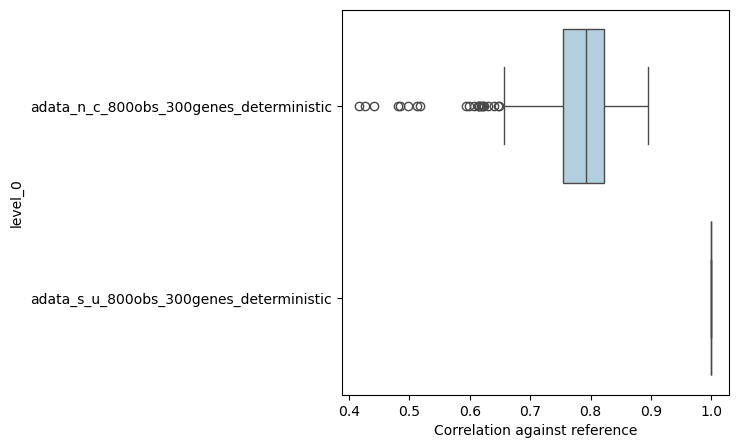

In [92]:
# same, but by cell
import matplotlib.pyplot as plt
# sns.clustermap(velocity_correlation_by_cell.fillna(0),figsize=(7,4),cmap='Blues')
plt.figure(figsize=(5,5))
sns.boxplot(data=velocity_correlation_by_cell.stack().reset_index(),y='level_0',x=0,palette='Blues')
plt.xlabel('Correlation against reference')

In [94]:
adata_800['adata_n_c_800obs_300genes_deterministic']

AnnData object with n_obs × n_vars = 800 × 300
    obs: 'true_t', 'n_counts', 'leiden', 'velocity_self_transition', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'Velocity confidence'
    var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'leiden', 'log1p', 'neighbors', 'pca', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'spliced', 'spliced_nuc', 'unspliced', 'velocity'
    obsp: 'connectivities', 'distances'

In [112]:
leiden_s_u = adata_800['adata_s_u_800obs_300genes_deterministic'].obs['leiden']
velocity_conf_n_c = adata_800['adata_n_c_800obs_300genes_deterministic'].obs['velocity_confidence']
velocity_conf_s_u = adata_800['adata_s_u_800obs_300genes_deterministic'].obs['velocity_confidence']

In [113]:
velo_corr_cell = pd.DataFrame(velocity_correlation_by_cell.T)
velo_corr_cell['leiden'] = leiden_s_u 
velo_corr_cell['velocity_conf_n_c'] = velocity_conf_n_c
velo_corr_cell['velocitty_conf_s_u'] = velocity_conf_s_u


In [115]:
velo_corr_cell.sort_values('adata_n_c_800obs_300genes_deterministic')

,adata_n_c_800obs_300genes_deterministic,adata_s_u_800obs_300genes_deterministic,leiden,velocity_conf_n_c,velocitty_conf_s_u
636,0.416841,1.0,0,0.223026,0.331097
633,0.426178,1.0,0,0.244012,0.411039
667,0.441608,1.0,0,0.146571,0.192935
634,0.481344,1.0,0,0.321913,0.520869
650,0.484368,1.0,2,0.286981,0.492363
...,...,...,...,...,...
506,0.882112,1.0,0,0.721377,0.769232
313,0.883280,1.0,2,0.737333,0.772183
309,0.884755,1.0,2,0.735751,0.763144
315,0.888396,1.0,2,0.800482,0.826753


<Axes: xlabel='None', ylabel='adata_n_c_800obs_300genes_deterministic'>

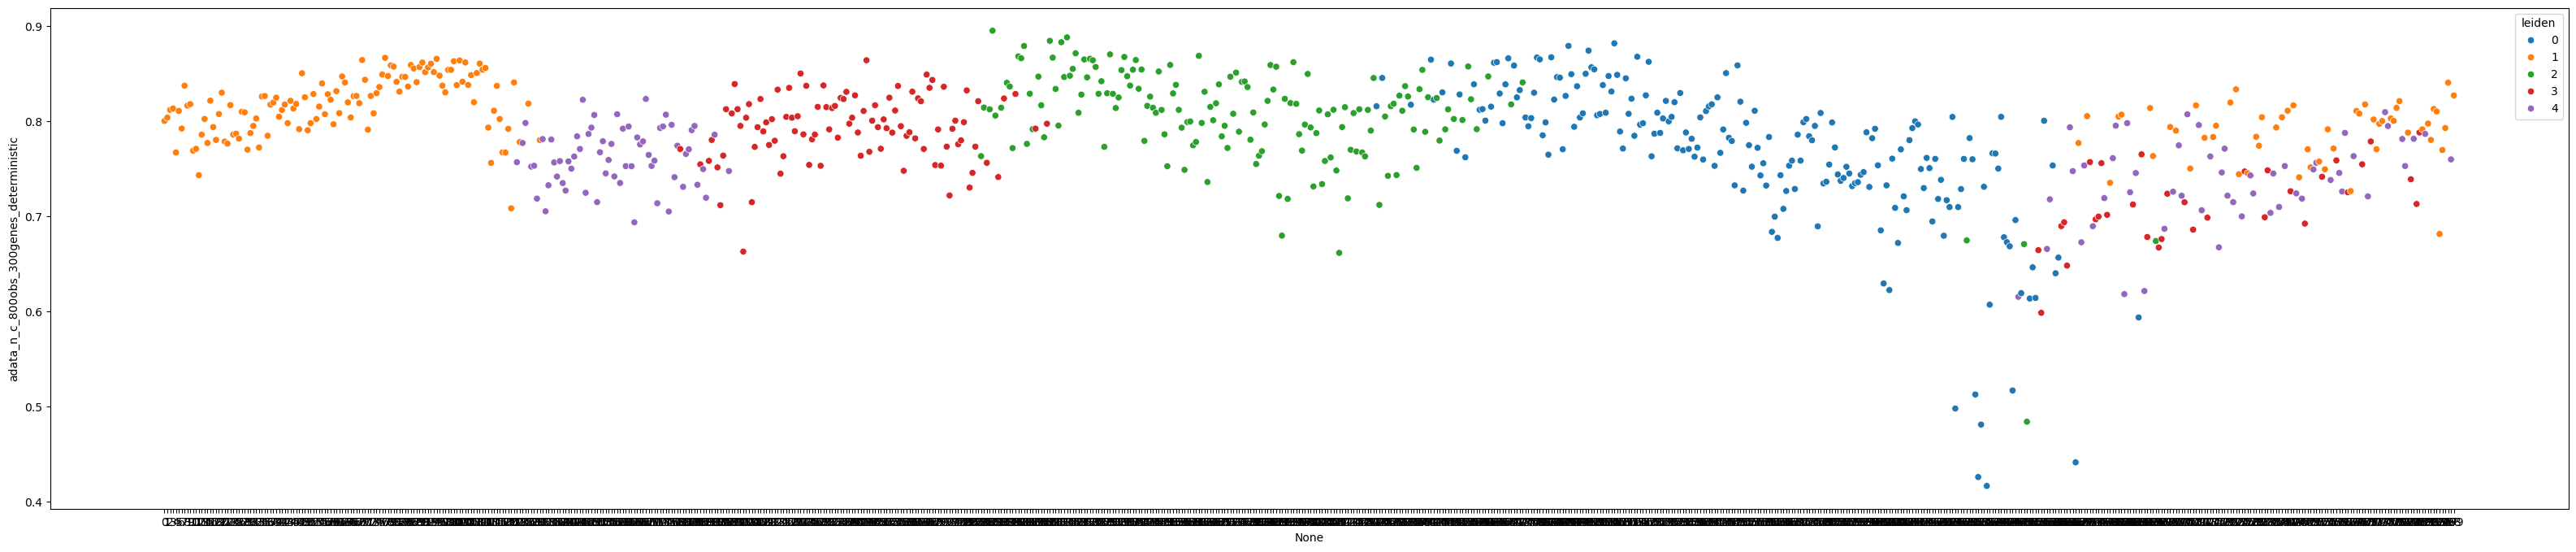

In [105]:
plt.figure(figsize=(40,8))
sns.scatterplot(data = velo_corr_cell, x = velo_corr_cell.index, y = 'adata_n_c_800obs_300genes_deterministic' , hue='leiden' )

- extreme velo differences between modalities happen mostly in leiden cluster 0. 

<Axes: xlabel='None', ylabel='velocitty_conf_s_u'>

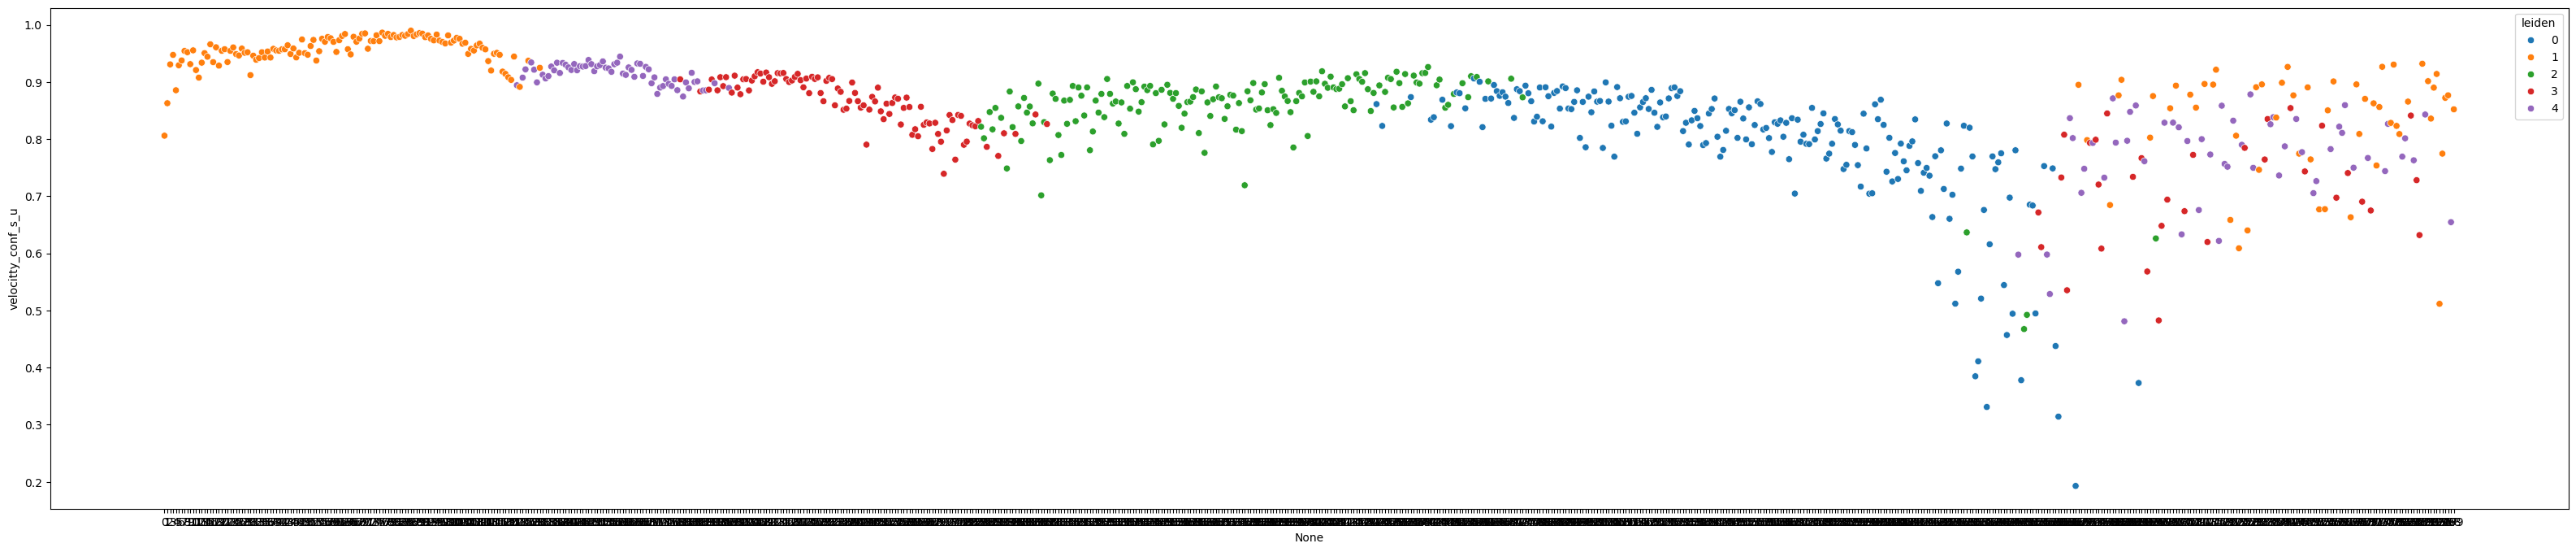

In [118]:
plt.figure(figsize=(40,8))
sns.scatterplot(data = velo_corr_cell, x = velo_corr_cell.index, y = 'velocitty_conf_s_u' , hue='leiden' )

<Axes: xlabel='None', ylabel='velocity_conf_n_c'>

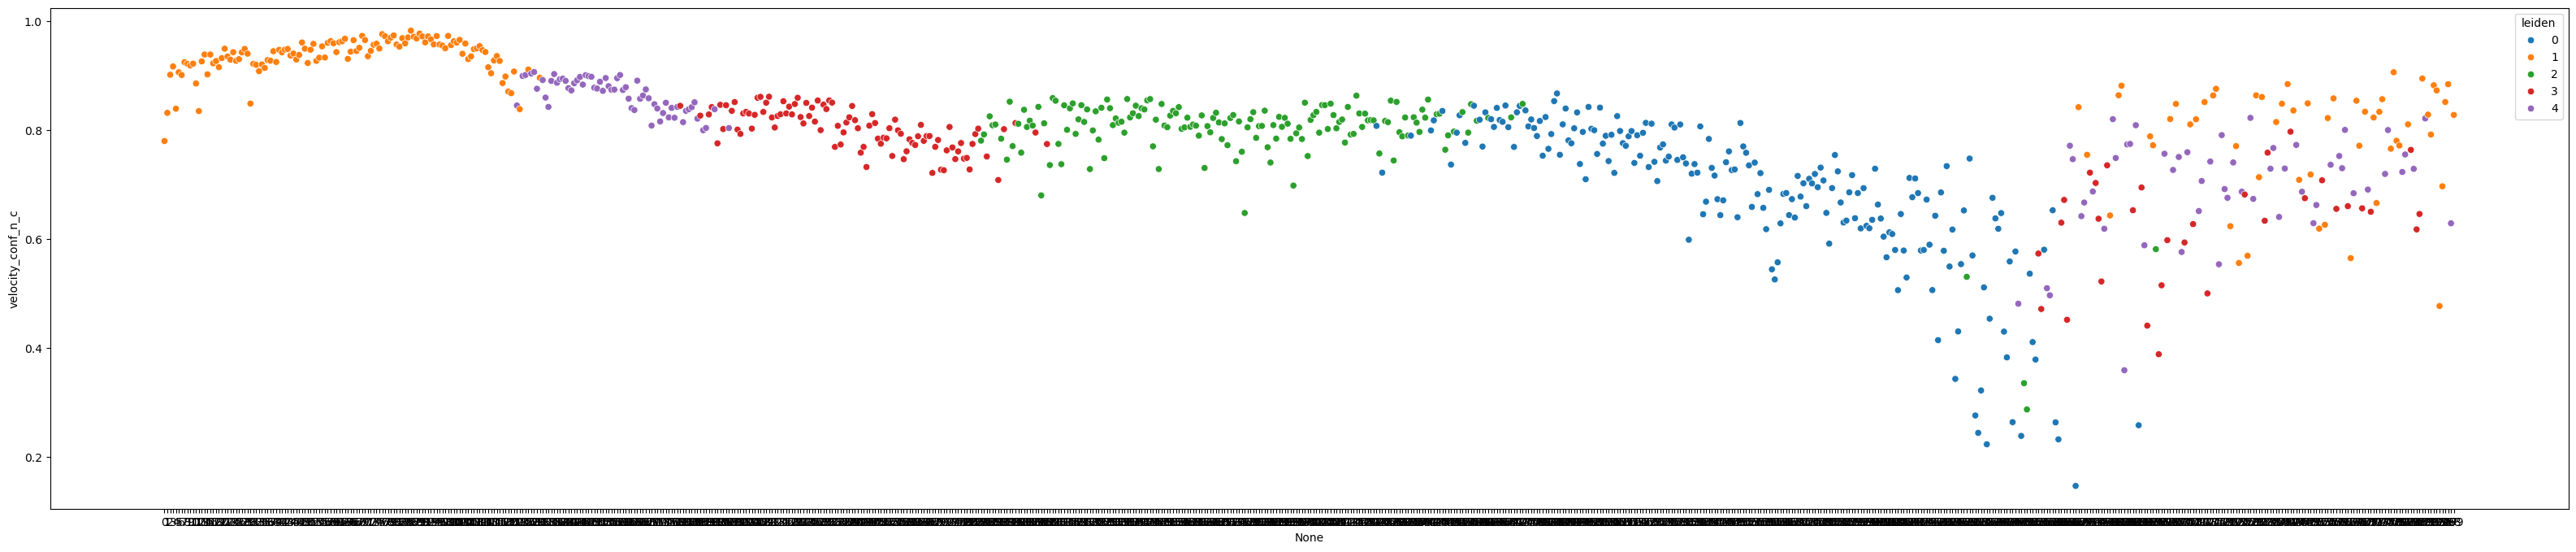

In [119]:
plt.figure(figsize=(40,8))
sns.scatterplot(data = velo_corr_cell, x = velo_corr_cell.index, y = 'velocity_conf_n_c' , hue='leiden' )

In [153]:
scv.tl.velocity_confidence(adata_800['adata_n_c_800obs_300genes_deterministic'])

--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)


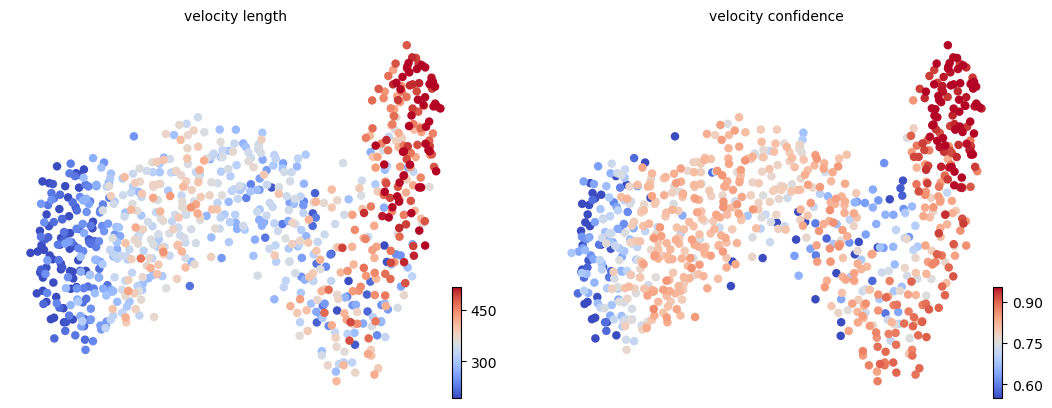

In [155]:
keys = 'velocity_length', 'velocity_confidence'
scv.pl.scatter(adata_800['adata_n_c_800obs_300genes_deterministic'], c=keys, cmap='coolwarm', perc=[5, 95])

--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)


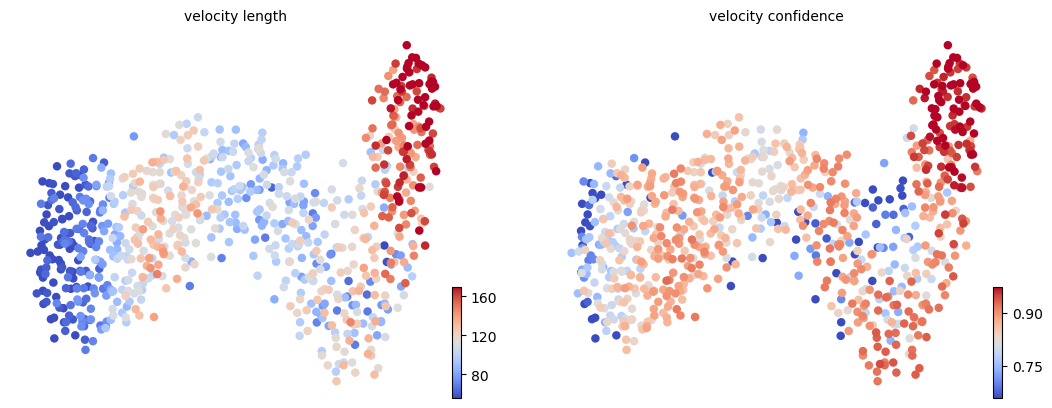

In [158]:
scv.tl.velocity_confidence(adata_800['adata_s_u_800obs_300genes_deterministic'])
keys = 'velocity_length', 'velocity_confidence'
scv.pl.scatter(adata_800['adata_s_u_800obs_300genes_deterministic'], c=keys, cmap='coolwarm', perc=[5, 95])

- Both of the modalities has the lowest values for velocity confidence for the cells differs in correlation the most. They can be filtered.

### Check the low correlated cells 

- check the times 

In [139]:
velo_corr_cell.sort_values('adata_n_c_800obs_300genes_deterministic').iloc[654]

adata_n_c_800obs_300genes_deterministic    0.831367
adata_s_u_800obs_300genes_deterministic         1.0
leiden                                            1
velocity_conf_n_c                          0.953246
velocitty_conf_s_u                         0.978731
Name: 82, dtype: object

In [129]:
b = (np.sum(adata_s_u_800obs.layers['unspliced'], axis=1) / np.sum(adata_s_u_800obs.layers['spliced'], axis=1))

In [134]:
np.argmin(b)

654

In [126]:
(np.sum(adata_n_c_800obs.layers['unspliced'], axis=1) / np.sum(adata_n_c_800obs.layers['spliced'], axis=1))

0.7827896542018831

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


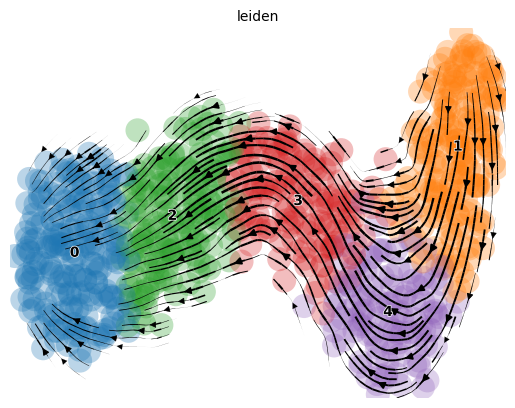

In [156]:
scv.pl.velocity_embedding_stream(adata_s_u_800obs, basis='umap', color='leiden')

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


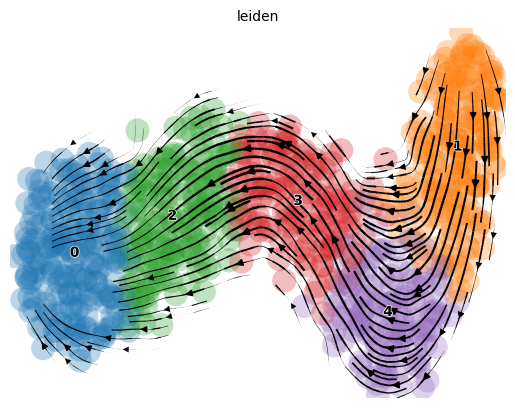

In [34]:
scv.pl.velocity_embedding_stream(adata_n_c_800obs, basis='umap', color='leiden')

# Check the important genes 

In [36]:
scv.tl.rank_velocity_genes(adata_s_u_800obs, groupby='leiden', min_corr=.3)
scv.tl.rank_velocity_genes(adata_n_c_800obs, groupby='leiden', min_corr=.3)

ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)


In [37]:
dfs = scv.get_df(adata_s_u_800obs.uns['rank_velocity_genes']['names'])
dfs.head(5)

,0,1,2,3,4
0,204,250,99,34,28
1,159,37,166,205,199
2,262,137,198,97,105
3,171,244,268,233,81
4,179,232,214,99,167


In [38]:
dfn = scv.get_df(adata_n_c_800obs.uns['rank_velocity_genes']['names'])
dfn.head(5)

,0,1,2,3,4
0,214,71,166,15,200
1,262,176,204,34,182
2,24,37,99,289,28
3,99,237,268,156,194
4,16,244,214,168,105


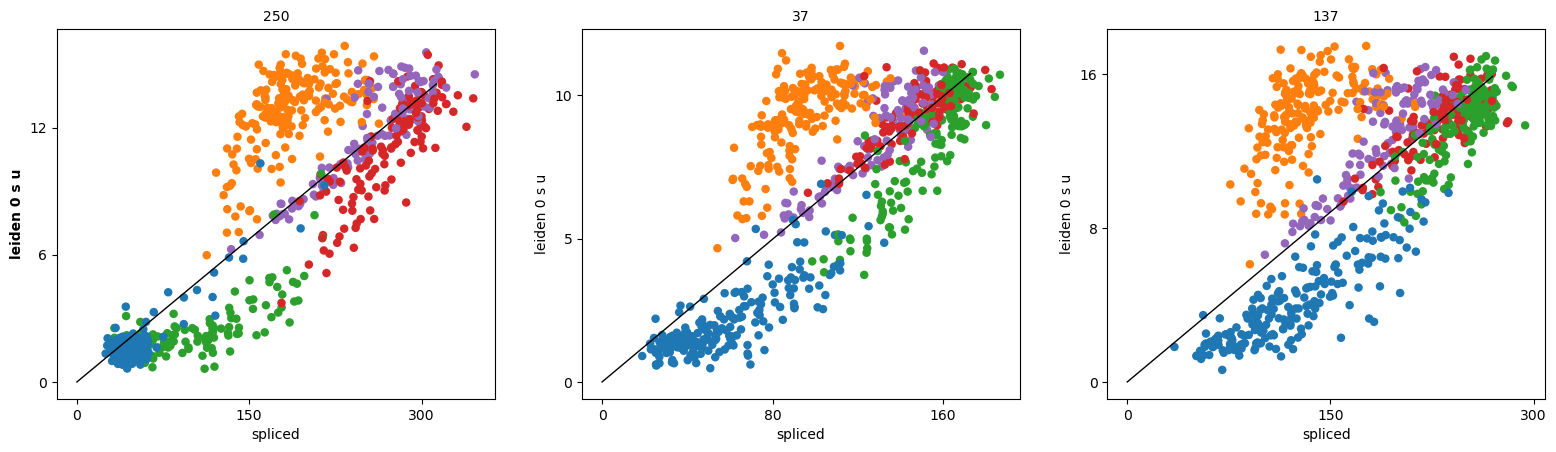

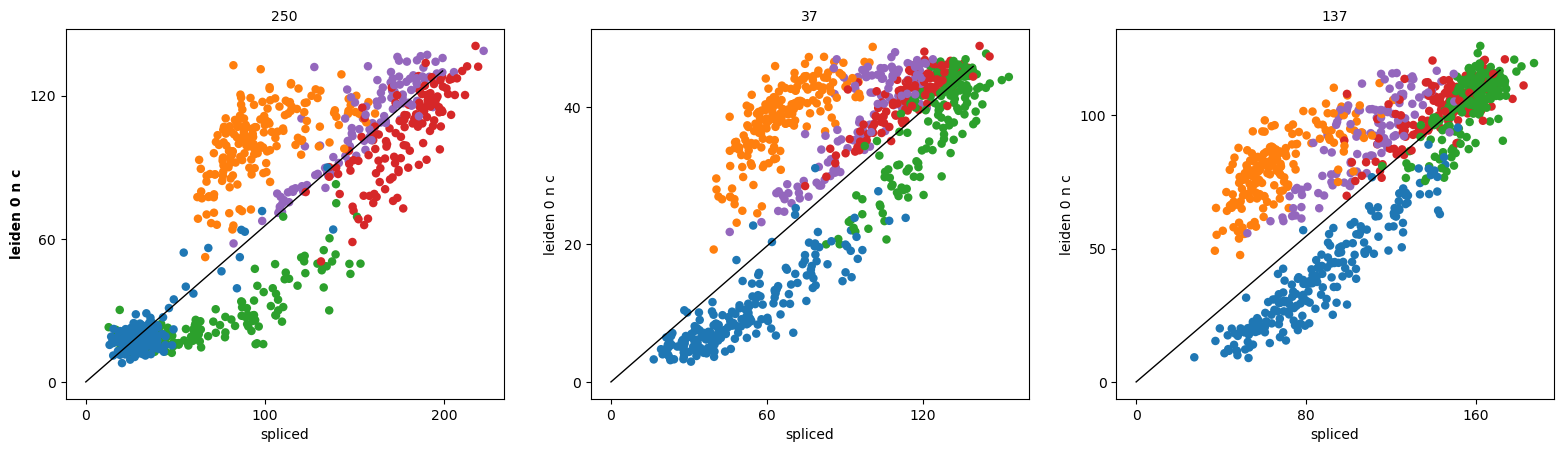

In [39]:
scv.pl.scatter(adata_s_u_800obs, dfs['1'][:3], ylabel='leiden 0 s_u', color='leiden')
scv.pl.scatter(adata_n_c_800obs, dfs['1'][:3], ylabel='leiden 0 n_c', color= 'leiden')

In [51]:
adata_n_c_800obs

AnnData object with n_obs × n_vars = 800 × 300
    obs: 'true_t', 'n_counts', 'leiden', 'velocity_self_transition'
    var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes', 'spearmans_score', 'velocity_score'
    uns: 'leiden', 'log1p', 'neighbors', 'pca', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params', 'leiden_colors', 'rank_velocity_genes'
    obsm: 'X_pca', 'X_umap', 'velocity_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'spliced', 'unspliced', 'velocity'
    obsp: 'connectivities', 'distances'

# Velocity Confidence

--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)


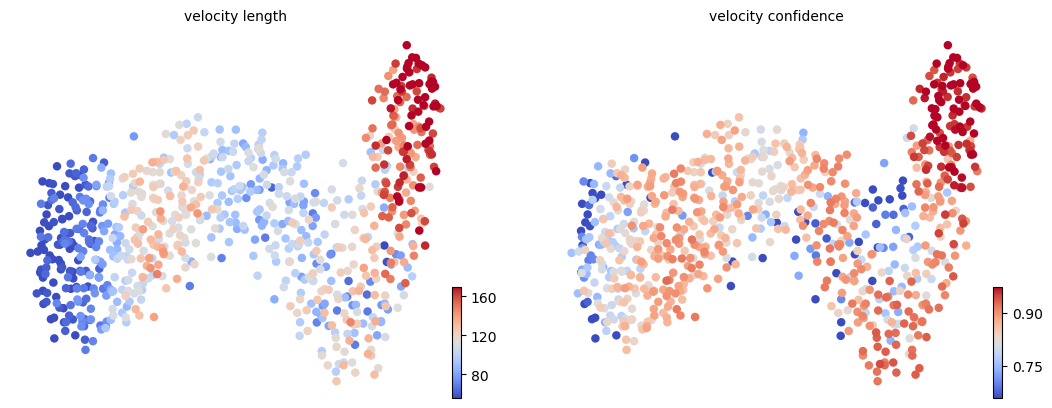

In [164]:
scv.tl.velocity_confidence(adata_s_u_800obs)
keys = 'velocity_length', 'velocity_confidence'
scv.pl.scatter(adata_s_u_800obs, c=keys, cmap='coolwarm', perc=[5, 95])

--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)


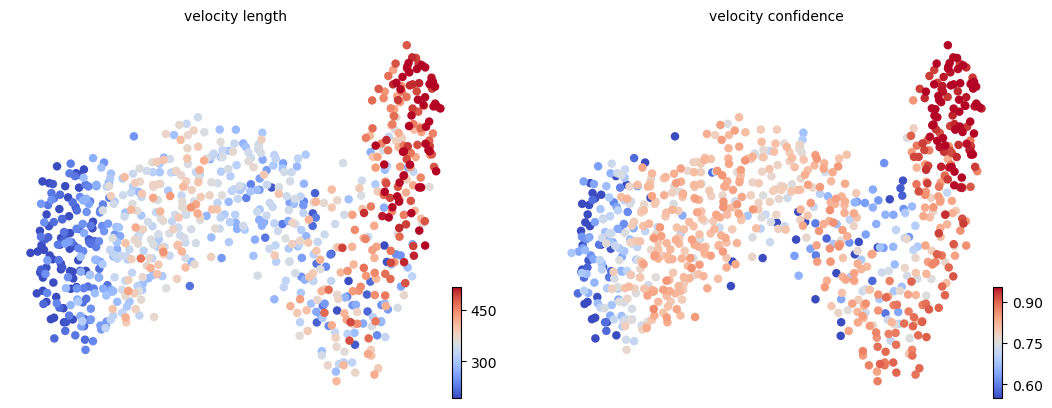

In [35]:
scv.tl.velocity_confidence(adata_n_c_800obs)
keys = 'velocity_length', 'velocity_confidence'
scv.pl.scatter(adata_n_c_800obs, c=keys, cmap='coolwarm', perc=[5, 95])

In [166]:
keys = ['velocity_length', 'velocity_confidence']
df = adata_s_u_800obs.obs.groupby('leiden')[keys].mean().T
df.style.background_gradient(cmap='coolwarm', axis=1)

leiden,0,1,2,3,4
velocity_length,68.244095,148.154984,115.598907,97.264740,106.864616
velocity_confidence,0.788621,0.916921,0.856813,0.828320,0.846804


In [167]:
keys = ['velocity_length', 'velocity_confidence']
df = adata_n_c_800obs.obs.groupby('leiden')[keys].mean().T
df.style.background_gradient(cmap='coolwarm', axis=1)

leiden,0,1,2,3,4
velocity_length,237.740829,453.092987,353.275055,316.103516,351.011292
velocity_confidence,0.680813,0.890113,0.799332,0.760218,0.789002


# Sign Accuracy 

In [202]:
adata_800['random'] = adata_random

In [208]:
scv.tl.velocity_graph(adata_800['random'])

computing velocity graph (using 1/24 cores)
    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [209]:
scv.pp.moments(adata_800['random'], n_pcs=None, n_neighbors=None)

computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [210]:
sign_accuracies=get_sign_accuracy(adata_800)

adata_n_c_800obs_300genes_deterministic


100%|██████████| 656/656 [00:00<00:00, 19666.80it/s]


adata_s_u_800obs_300genes_deterministic


100%|██████████| 656/656 [00:00<00:00, 16977.43it/s]


random


100%|██████████| 656/656 [00:00<00:00, 16225.74it/s]


<Axes: xlabel='Accuracy', ylabel='Model'>

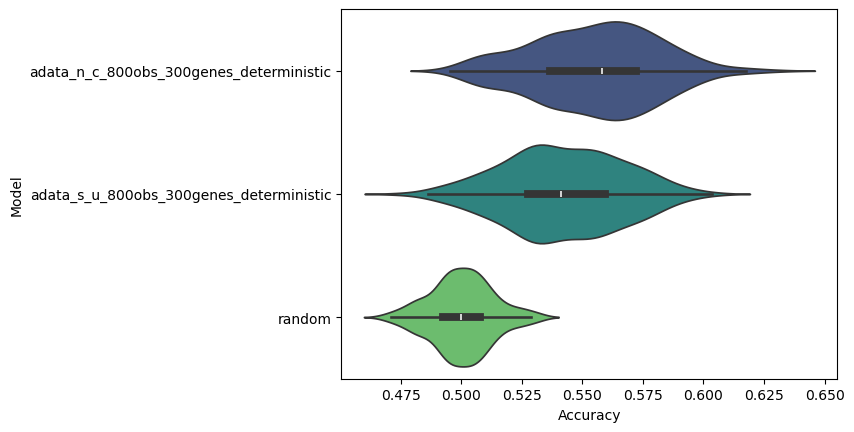

In [211]:
sns.violinplot(data=sign_accuracies,y='Model',x='Accuracy',palette='viridis')